In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

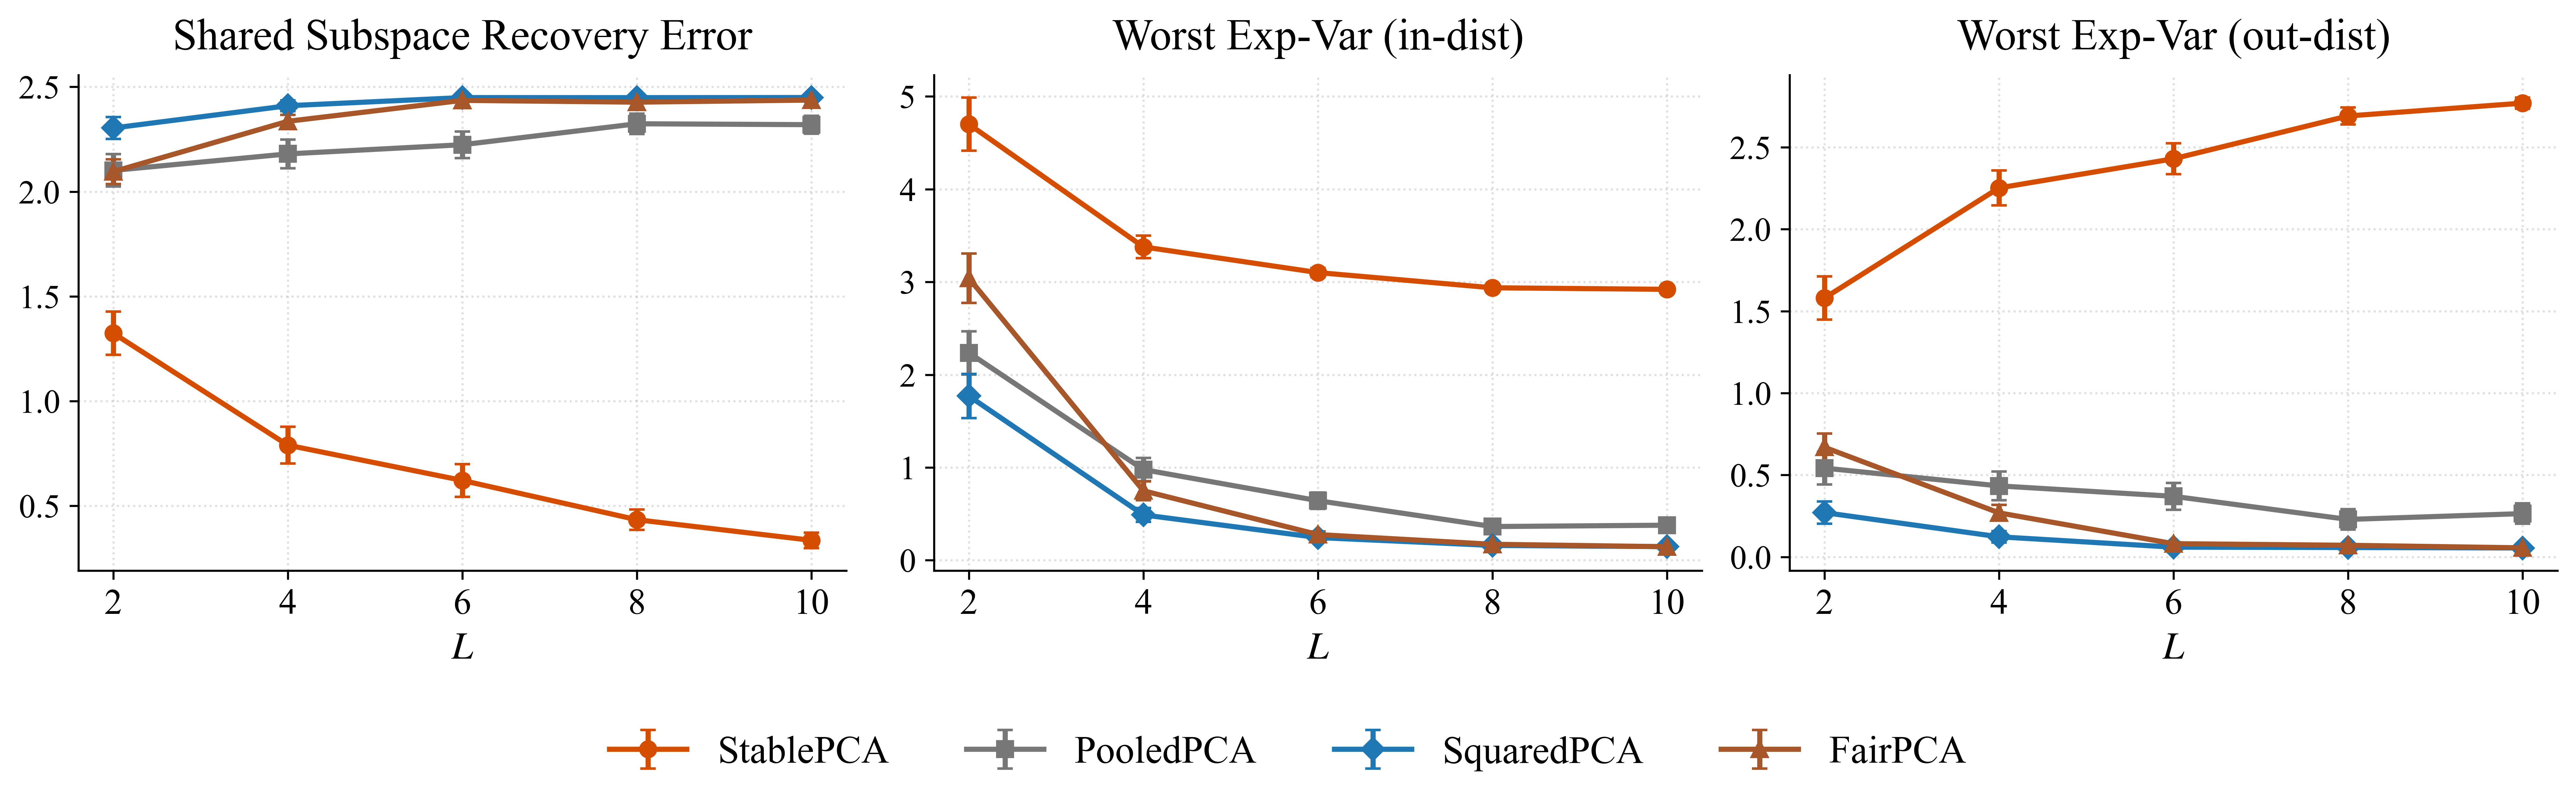

In [ ]:
# ------------------------------------------------------------
# NeurIPS-ish global style (as you specified)
# ------------------------------------------------------------
plt.rcParams.update({
    # --- NeurIPS-style, larger text for print ---
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "figure.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",

    # Scaled up for visibility in print
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 13,
    "legend.fontsize": 15,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
L_list = [2, 4, 6, 8, 10]

# Methods in the order you want in the plots
methods = ["stable", "pooled", "squared", "fair"]
method_labels = {
    "stable":  "StablePCA",
    "pooled":  "PooledPCA",
    "squared": "SquaredPCA",
    "fair":    "FairPCA",
}

# Colors consistent with your previous setup
method_colors = {
    "pooled":  "#777777",  # charcoal
    "stable":  "#D54E00",  # orange
    "squared": "#1F78B4",  # blue
    "fair":    "#A65628",  # gray
}

# Markers (just to visually separate curves)
method_markers = {
    "stable":  "o",
    "pooled":  "s",
    "squared": "D",
    "fair":    "^",
}

# ------------------------------------------------------------
# Arrays to hold means and (optionally) std errors
# shape: (n_L, n_methods)
# ------------------------------------------------------------
n_L = len(L_list)
n_m = len(methods)

subspace_err_mean = np.zeros((n_L, n_m))
subspace_err_se   = np.zeros((n_L, n_m))

expl_src_mean = np.zeros((n_L, n_m))
expl_src_se   = np.zeros((n_L, n_m))

expl_ood_mean = np.zeros((n_L, n_m))
expl_ood_se   = np.zeros((n_L, n_m))

# ------------------------------------------------------------
# Load and aggregate results
# ------------------------------------------------------------
results_dir = "../saved_results"
for iL, L in enumerate(L_list):
    fname = f"{results_dir}/results-OOD_L{L}.pkl"
    with open(fname, "rb") as f:
        results = pickle.load(f)  # list of dicts, length ~100

    # Collect per-method values across runs
    err_vals      = {m: [] for m in methods}
    expl_src_vals = {m: [] for m in methods}
    expl_ood_vals = {m: [] for m in methods}

    for res in results:
        for m in methods:
            err_vals[m].append(res["err"][m])
            expl_src_vals[m].append(res["expl_var_src"][m])
            expl_ood_vals[m].append(res["expl_var_ood"][m])

    # Convert to arrays and compute mean + standard error
    for j, m in enumerate(methods):
        e = np.array(err_vals[m])
        s_src = np.array(expl_src_vals[m])
        s_ood = np.array(expl_ood_vals[m])

        subspace_err_mean[iL, j] = e.mean()
        subspace_err_se[iL, j]   = e.std(ddof=1) / np.sqrt(len(e))

        expl_src_mean[iL, j] = s_src.mean()
        expl_src_se[iL, j]   = s_src.std(ddof=1) / np.sqrt(len(s_src))

        expl_ood_mean[iL, j] = s_ood.mean()
        expl_ood_se[iL, j]   = s_ood.std(ddof=1) / np.sqrt(len(s_ood))

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4))
plt.subplots_adjust(bottom=0.23, wspace=0.25)

# Helper to plot one panel
def plot_panel(ax, y_mean, y_se, ylabel, title):
    for j, m in enumerate(methods):
        ax.errorbar(
            L_list,
            y_mean[:, j],
            yerr=y_se[:, j],
            label=method_labels[m],
            color=method_colors[m],
            marker=method_markers[m],
            linestyle="-" if m == "stable" else "-",
            capsize=3,
        )

    ax.set_xlabel(r"$L$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=10)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.4)

    # Only left and bottom spines visible (NeurIPS-ish clean look)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# 1) Subspace error
plot_panel(
    ax0,
    subspace_err_mean,
    subspace_err_se,
    ylabel=None,
    # ylabel=r"$\|\!AA^\top - \widehat{M}\|_F^2$",
    title="Shared Subspace Recovery Error",
)

# 2) Worst-case explained variance (in-dist)
plot_panel(
    ax1,
    expl_src_mean,
    expl_src_se,
    ylabel=None,
    # ylabel=r"$\min_l \langle \Sigma^{(l)}, \widehat{M} \rangle$",
    title="Worst Exp-Var (in-dist)",
)

# 3) Worst-case explained variance (out-dist)
plot_panel(
    ax2,
    expl_ood_mean,
    expl_ood_se,
    ylabel=None,
    # ylabel=r"$\min_l \langle \Sigma^{(l)}, \widehat{M} \rangle$",
    title="Worst Exp-Var (out-dist)",
)

# Shared legend (top center)
handles, labels = ax0.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("Figures/summary_OOD.png", bbox_inches="tight", dpi=600)
plt.show()
